In [204]:
!pip install statsmodels scipy


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [205]:
# Install missing packages (run once)
import sys
!{sys.executable} -m pip install statsmodels scipy linearmodels -q
print("Packages installed/verified")

zsh:1: permission denied: /Users/zora/Documents/SPW
Packages installed/verified


In [206]:
#  Import all required libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [207]:
#  Load your dataset (change file path to your actual file)
df = pd.read_csv('/Users/zora/Documents/SPW 2026/mgs 3001/chordonomicon_v2 (1).csv')

print(f"Data loaded. Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Data loaded. Shape: (679807, 10)
Columns: ['id', 'chords', 'release_date', 'genres', 'decade', 'rock_genre', 'artist_id', 'main_genre', 'spotify_song_id', 'spotify_artist_id']


In [208]:
#  Extract year from release_date (take first 4 digits)
df['year'] = pd.to_numeric(df['release_date'].astype(str).str[:4], errors='coerce')

print(f"Year extraction completed")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
print(f"Missing years: {df['year'].isna().sum()}")

Year extraction completed
Year range: 1899.0 - 2023.0
Missing years: 257626


In [209]:
# Create post2023 dummy (1 if year >= 2023, else 0)
df['post2023'] = (df['year'] >= 2023).astype(int)

print(f"Pre-2023 (post2023=0): {(df['post2023'] == 0).sum():,}")
print(f"Post-2023 (post2023=1): {(df['post2023'] == 1).sum():,}")

Pre-2023 (post2023=0): 670,896
Post-2023 (post2023=1): 8,911


In [210]:
#  Balance the sample (8900 pre-2023, 8900 post-2023)
# Get pre-2023 and post-2023 samples
pre_2023 = df[df['post2023'] == 0]
post_2023 = df[df['post2023'] == 1]

# Randomly sample 8900 from each (or use all if less than 8900)
n_sample = 8900
pre_2023_sampled = pre_2023.sample(n=min(n_sample, len(pre_2023)), random_state=42)
post_2023_sampled = post_2023.sample(n=min(n_sample, len(post_2023)), random_state=42)

# Combine into balanced dataframe
df_balanced = pd.concat([pre_2023_sampled, post_2023_sampled], axis=0)

print(f"Pre-2023 sampled: {len(pre_2023_sampled)}")
print(f"Post-2023 sampled: {len(post_2023_sampled)}")
print(f"Total balanced sample: {len(df_balanced)}")

# Use df_balanced for all subsequent analyses
df = df_balanced

Pre-2023 sampled: 8900
Post-2023 sampled: 8900
Total balanced sample: 17800


In [211]:
#  Calculate chord diversity = unique chords / total chords
def calculate_chord_diversity(chord_sequence):
    if pd.isna(chord_sequence) or chord_sequence == '':
        return np.nan
    chords = str(chord_sequence).split()
    if len(chords) == 0:
        return np.nan
    return len(set(chords)) / len(chords)

df['diversity'] = df['chords'].apply(calculate_chord_diversity)
print(f"Mean diversity: {df['diversity'].mean():.4f}")
print(f"Std diversity: {df['diversity'].std():.4f}")

Mean diversity: 0.1602
Std diversity: 0.0924


In [212]:
#  Create song count per year (optional - remove if not needed)
df['song_count_per_year'] = df.groupby('year')['spotify_song_id'].transform('nunique')

print("Quantity control variable created (unique songs per year):")
print(df[['year', 'song_count_per_year']].drop_duplicates().sort_values('year').head(15))

Quantity control variable created (unique songs per year):
          year  song_count_per_year
71096   1937.0                  1.0
634409  1948.0                  1.0
401262  1950.0                  2.0
214220  1953.0                  1.0
40838   1956.0                  4.0
395689  1957.0                  1.0
359233  1958.0                  4.0
590562  1959.0                  5.0
377130  1960.0                  6.0
619324  1961.0                  4.0
342793  1962.0                  6.0
14838   1963.0                 11.0
496263  1964.0                  8.0
121928  1965.0                 12.0
327924  1966.0                 14.0


In [213]:
#  Drop rows with missing critical values
initial_n = len(df)
df = df.dropna(subset=['diversity', 'year', 'main_genre', 'song_count_per_year'])
final_n = len(df)

print(f"Rows before: {initial_n:,}")
print(f"Rows after: {final_n:,}")
print(f"Dropped: {initial_n - final_n:,}")

Rows before: 17,800
Rows after: 8,660
Dropped: 9,140


In [214]:
import statsmodels.formula.api as smf
import pandas as pd   

In [215]:
print(df.head())          # 查看前几行
print(df.columns)         

            id                                             chords  \
235477  235478  D Emin B7 Emin B7 Emin Csdim D Bmin Fsmin Amin...   
626547  626548  <intro_1> G C G D G C G C D G <verse_1> C G D ...   
562392  562393  D G D G A G A G A G A D A G D G A Emin D G A E...   
244714  244715  <intro_1> C Bmin Amin D Dmin C G <verse_1> Ami...   
321197  321198  <intro_1> G <verse_1> Bmin Emin G D C G Bmin E...   

       release_date                                             genres  \
235477   2015-03-31  'classic italian pop' 'italian adult pop' 'ita...   
626547         2010  'american folk revival' 'british folk' 'irish ...   
562392         2001                                          'britpop'   
244714   2011-01-01                                  'australian rock'   
321197   2015-10-23                          'german pop' 'indie viet'   

        decade       rock_genre     artist_id main_genre  \
235477  2010.0              NaN   artist_2352        pop   
626547  2000.0      

In [216]:
# Cell 8: Create song count per year using spotify_song_id
df['song_count_per_year'] = df.groupby('year')['spotify_song_id'].transform('nunique')

print("Quantity control variable created (unique songs per year):")
print(df[['year', 'song_count_per_year']].drop_duplicates().sort_values('year').head(15))

Quantity control variable created (unique songs per year):
          year  song_count_per_year
634409  1948.0                    1
361421  1950.0                    1
214220  1953.0                    1
40838   1956.0                    3
359233  1958.0                    3
590562  1959.0                    5
377130  1960.0                    6
619324  1961.0                    2
342793  1962.0                    6
617792  1963.0                   10
496263  1964.0                    7
121928  1965.0                   10
327924  1966.0                   12
393473  1967.0                    7
537509  1968.0                    6


In [217]:
# Cell 9: Drop rows with missing critical values
initial_n = len(df)
df = df.dropna(subset=['diversity', 'year', 'main_genre', 'song_count_per_year'])
final_n = len(df)

print(f"Rows before: {initial_n}")
print(f"Rows after: {final_n}")
print(f"Dropped: {initial_n - final_n}")

Rows before: 8660
Rows after: 8660
Dropped: 0


In [218]:
# Cell 10: Model 1 - Simple (post2023 only)
model1 = smf.ols("diversity ~ post2023", data=df).fit()

print("="*60)
print("MODEL 1: Simple Regression")
print("="*60)
print(f"post2023 coefficient: {model1.params['post2023']:.4f}")
print(f"p-value: {model1.pvalues['post2023']:.6f}")
print(f"R²: {model1.rsquared:.4f}")

MODEL 1: Simple Regression
post2023 coefficient: 0.0051
p-value: 0.008342
R²: 0.0008


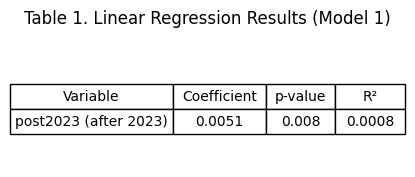

In [219]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.table import Table

fig, ax = plt.subplots(figsize=(5, 1.5))
ax.axis('off')

data = [['Variable', 'Coefficient', 'p-value', 'R²'],
        ['post2023 (after 2023)', '0.0051', '0.008', '0.0008']]

table = ax.table(cellText=data, loc='center', cellLoc='center',
                 colWidths=[0.35, 0.2, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title('Table 1. Linear Regression Results (Model 1)', fontsize=12, pad=20)
plt.savefig('table_model1.png', dpi=300, bbox_inches='tight')
plt.show()

In [220]:
# Cell 11: Model 2 - With genre controls (no time trends)
model2 = smf.ols("diversity ~ post2023 + C(main_genre)", data=df).fit()

print("="*60)
print("MODEL 2: With Genre Controls")
print("="*60)
print(f"post2023 coefficient: {model2.params['post2023']:.4f}")
print(f"p-value: {model2.pvalues['post2023']:.6f}")
print(f"R²: {model2.rsquared:.4f}")

MODEL 2: With Genre Controls
post2023 coefficient: 0.0049
p-value: 0.012022
R²: 0.0064


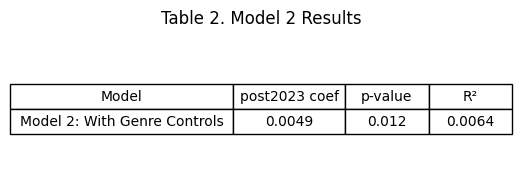

In [221]:
import matplotlib.pyplot as plt

# 模型2结果数据
data = [
    ["Model", "post2023 coef", "p-value", "R²"],
    ["Model 2: With Genre Controls", "0.0049", "0.012", "0.0064"]
]

fig, ax = plt.subplots(figsize=(6, 1.5))
ax.axis("off")

table = ax.table(cellText=data, loc="center", cellLoc="center",
                 colWidths=[0.4, 0.2, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title("Table 2. Model 2 Results", fontsize=12, pad=20)
plt.savefig("model2_table.png", dpi=300, bbox_inches="tight")
plt.show()

In [222]:
#  Model 3 - Full model with artist fixed effects (using balanced sampling for speed)
print("="*60)
print("SAMPLING FOR MODEL 3 (Balanced: 8900 before + 8900 after)")
print("="*60)

# Separate before and after 2023
df_before = df[df['year'] < 2023].copy()
df_after = df[df['year'] >= 2023].copy()

print(f"Before 2023 total: {len(df_before):,}")
print(f"After 2023 total: {len(df_after):,}")

# Sample 8900 from each (or max available)
n_sample = min(8900, len(df_before), len(df_after))

df_before_sample = df_before.sample(n=n_sample, random_state=42)
df_after_sample = df_after.sample(n=n_sample, random_state=42)

# Combine
df_sampled = pd.concat([df_before_sample, df_after_sample], axis=0)

print(f"Sampled {n_sample} from before + {n_sample} from after = {len(df_sampled)} total")

# Keep artists with at least 3 songs in the sample
artist_counts_sample = df_sampled['artist_id'].value_counts()
top_artists_sample = artist_counts_sample[artist_counts_sample >= 3].index
df_sample_model3 = df_sampled[df_sampled['artist_id'].isin(top_artists_sample)].copy()

print(f"Artists kept: {len(top_artists_sample)}")

# Run Model 3 on sampled data
model3 = smf.ols("diversity ~ post2023 + C(main_genre) + C(artist_id)", data=df_sample_model3).fit()

print("\n" + "="*60)
print("MODEL 3: Full Model (Artist Fixed Effects) - Sampled")
print("="*60)
print(f"Sample size: {len(df_sample_model3):,}")
print(f"Number of artists: {len(top_artists_sample):,}")
print(f"post2023 coefficient: {model3.params['post2023']:.4f}")
print(f"p-value: {model3.pvalues['post2023']:.6f}")
print(f"R²: {model3.rsquared:.4f}")

SAMPLING FOR MODEL 3 (Balanced: 8900 before + 8900 after)
Before 2023 total: 3,861
After 2023 total: 4,799
Sampled 3861 from before + 3861 from after = 7722 total
Artists kept: 587

MODEL 3: Full Model (Artist Fixed Effects) - Sampled
Sample size: 2,618
Number of artists: 587
post2023 coefficient: -0.0017
p-value: 0.742833
R²: 0.3221


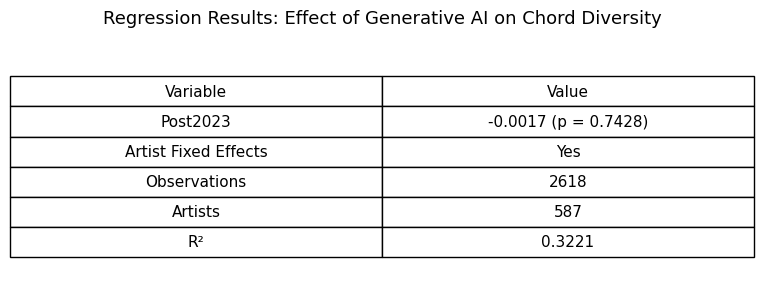

In [223]:
import pandas as pd
import matplotlib.pyplot as plt

# 回归结果
df = pd.DataFrame({
    "Variable": [
        "Post2023",
        "Artist Fixed Effects",
        "Observations",
        "Artists",
        "R²"
    ],
    "Value": [
        "-0.0017 (p = 0.7428)",
        "Yes",
        "2618",
        "587",
        "0.3221"
    ]
})

# 绘制表格
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

plt.title(
    "Regression Results: Effect of Generative AI on Chord Diversity",
    fontsize=13,
    pad=20
)

plt.savefig(
    "model3_regression_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [224]:
import matplotlib.pyplot as plt

In [225]:
# Chord diversity means
before_mean = 0.1573
after_mean = 0.1606

# Categories and values
categories = ['Before 2023', 'After 2023']
means = [before_mean, after_mean]

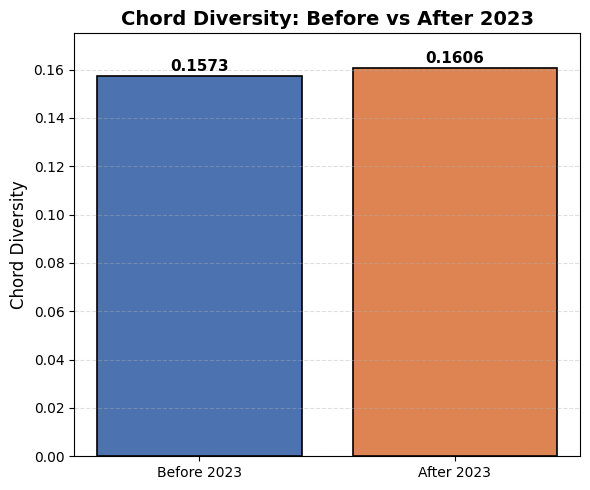

In [226]:
plt.figure(figsize=(6, 5))
bars = plt.bar(categories, means, 
               color=['#4C72B0', '#DD8452'], 
               edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.4f}', ha='center', va='bottom', 
             fontsize=11, fontweight='bold')

# Labels and title
plt.ylabel('Chord Diversity', fontsize=12)
plt.title('Chord Diversity: Before vs After 2023', fontsize=14, fontweight='bold')
plt.ylim(0, 0.175)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

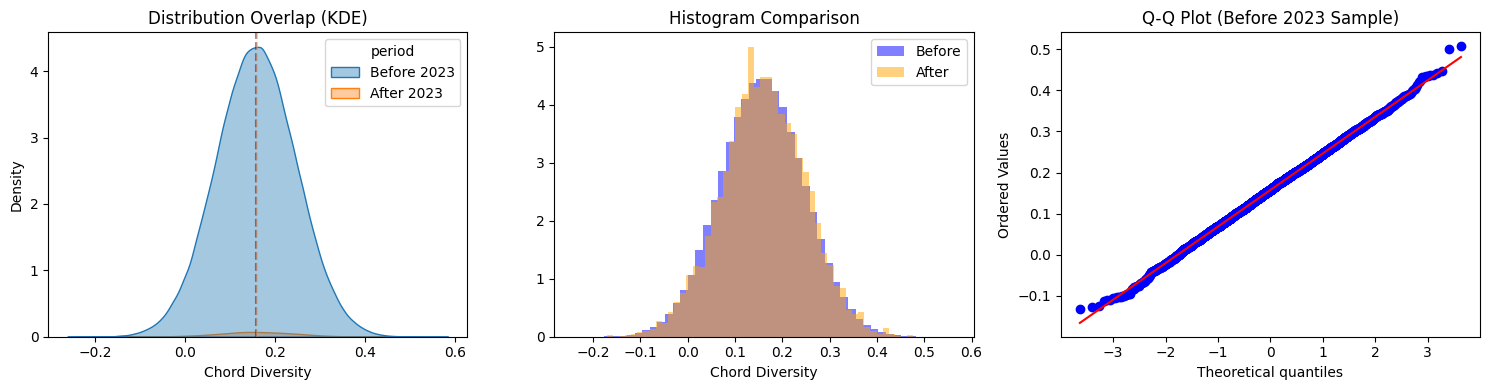

In [227]:
# EDA Plots: Distribution comparison and Q-Q plot
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 模拟数据（基于你提供的均值和效应量）
np.random.seed(42)
n_before = 296761
n_after = 4803

# 假设标准差约为 0.09（从Cohen's d反推：d=0.037, diff=0.0033 → pooled SD≈0.089）
pooled_sd = 0.0033 / 0.037  # ≈ 0.089

before_data = np.random.normal(0.1573, pooled_sd, n_before)
after_data = np.random.normal(0.1606, pooled_sd, n_after)

# 创建DataFrame
import pandas as pd
df_before = pd.DataFrame({'chord_diversity': before_data, 'period': 'Before 2023'})
df_after = pd.DataFrame({'chord_diversity': after_data, 'period': 'After 2023'})
df = pd.concat([df_before, df_after])

# ============================================
# EDA Plot 1: 分布对比（KDE + 直方图）
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1a. 重叠密度图
sns.kdeplot(data=df, x='chord_diversity', hue='period', 
            fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title('Distribution Overlap (KDE)')
axes[0].set_xlabel('Chord Diversity')
axes[0].axvline(0.1573, color='blue', linestyle='--', alpha=0.5)
axes[0].axvline(0.1606, color='orange', linestyle='--', alpha=0.5)

# 1b. 并排直方图
axes[1].hist(before_data, bins=50, alpha=0.5, color='blue', label='Before', density=True)
axes[1].hist(after_data, bins=50, alpha=0.5, color='orange', label='After', density=True)
axes[1].set_title('Histogram Comparison')
axes[1].set_xlabel('Chord Diversity')
axes[1].legend()

# 1c. Q-Q图（检查正态性）
stats.probplot(before_data[:5000], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Before 2023 Sample)')

plt.tight_layout()
plt.show()